# EDA — Lead Conversion Dataset


## 1. Setup & Data Overview


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Data/clean_df.csv')  # adjust path if needed

# Drop non-predictive identifier columns
df.drop(columns=['Prospect ID', 'Lead Number'], inplace=True)

print(f'Shape: {df.shape}')
df.head()


Shape: (9240, 17)


,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Tags,City,Asymmetrique Activity Score,Asymmetrique Profile Score,A free copy of Mastering The Interview,Last Notable Activity,is_india
0,API,Olark Chat,No,0,0.0,0,0,Page Visited on Website,Not Specified,Unemployed,Interested in other courses,Unknown,15.0,15.0,No,Modified,No
1,API,Organic Search,No,0,5.0,674,2,Email Opened,Not Specified,Unemployed,Ringing,Unknown,15.0,15.0,No,Email Opened,Yes
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2,Email Opened,Business Administration,Student,Will revert after reading the email,Mumbai,14.0,20.0,Yes,Email Opened,Yes
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1,Unreachable,Media and Advertising,Unemployed,Ringing,Mumbai,13.0,17.0,No,Modified,Yes
4,Landing Page Submission,Google,No,1,2.0,1428,1,Converted to Lead,Not Specified,Unemployed,Will revert after reading the email,Mumbai,15.0,18.0,No,Modified,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9240 non-null   object 
 1   Lead Source                             9240 non-null   object 
 2   Do Not Email                            9240 non-null   object 
 3   Converted                               9240 non-null   int64  
 4   TotalVisits                             9240 non-null   float64
 5   Total Time Spent on Website             9240 non-null   int64  
 6   Page Views Per Visit                    9240 non-null   int64  
 7   Last Activity                           9240 non-null   object 
 8   Specialization                          9240 non-null   object 
 9   What is your current occupation         9240 non-null   object 
 10  Tags                                    9240 non-null   obje

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Converted,9240.0,0.385390,0.486714,0.0,0.0,0.0,1.0,1.0
TotalVisits,9240.0,3.355628,3.358788,0.0,1.0,3.0,5.0,21.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9240.0,2.347511,2.022311,0.0,1.0,2.0,3.0,11.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.0,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.0,20.0


In [5]:
# Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
mv = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
mv[mv['Missing Count'] > 0].sort_values('Missing %', ascending=False)


,Missing Count,Missing %
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Score,4218,45.65


In [6]:
# Column groups — semantic classification, not just dtype
numerical_cols = [
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

categorical_cols = [
    'Lead Origin',
    'Lead Source',
    'Do Not Email',
    'Last Activity',
    'Specialization',
    'What is your current occupation',
    'Tags',
    'City',
    'A free copy of Mastering The Interview',
    'Last Notable Activity',
    'is_india'
]

target = 'Converted'


## 2. Visual Graphs — Key Features


### 2.1 Numerical Features vs Target (Boxplots)

Distribution of each numerical feature split by Converted = 0 vs 1.


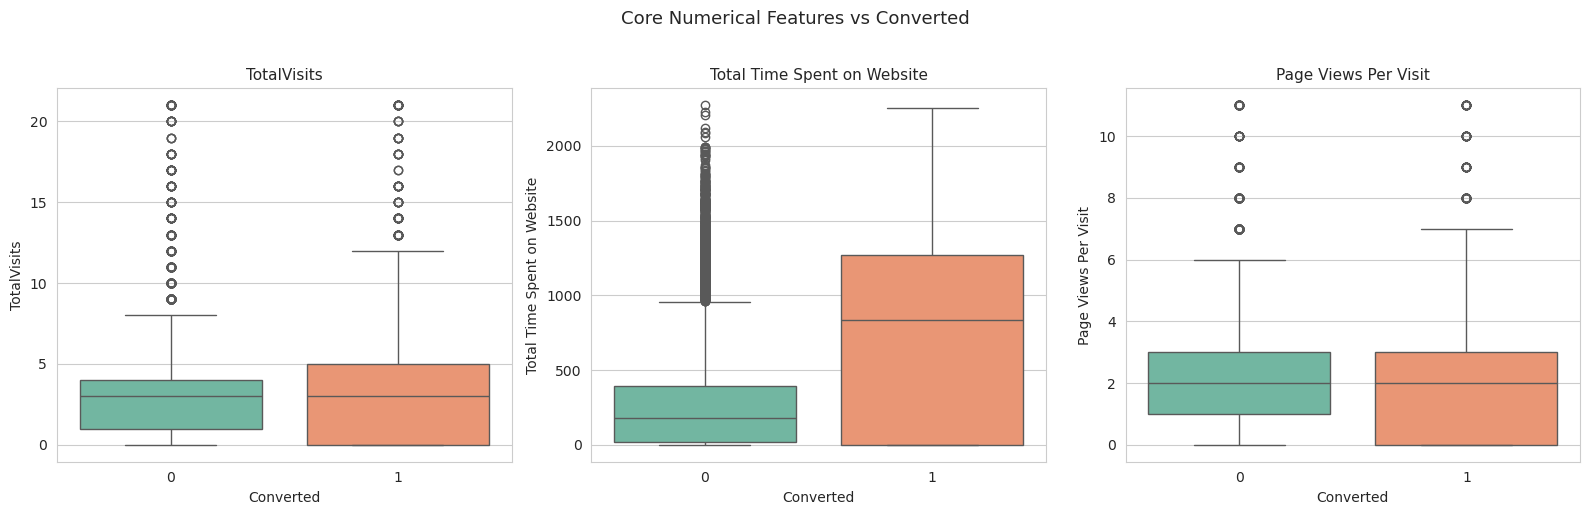

In [7]:
# Core numerical features — no missing values
core_num = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, core_num):
    sns.boxplot(data=df, x='Converted', y=col, ax=ax, palette='Set2')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Converted')
    ax.set_ylabel(col)
plt.suptitle('Core Numerical Features vs Converted', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


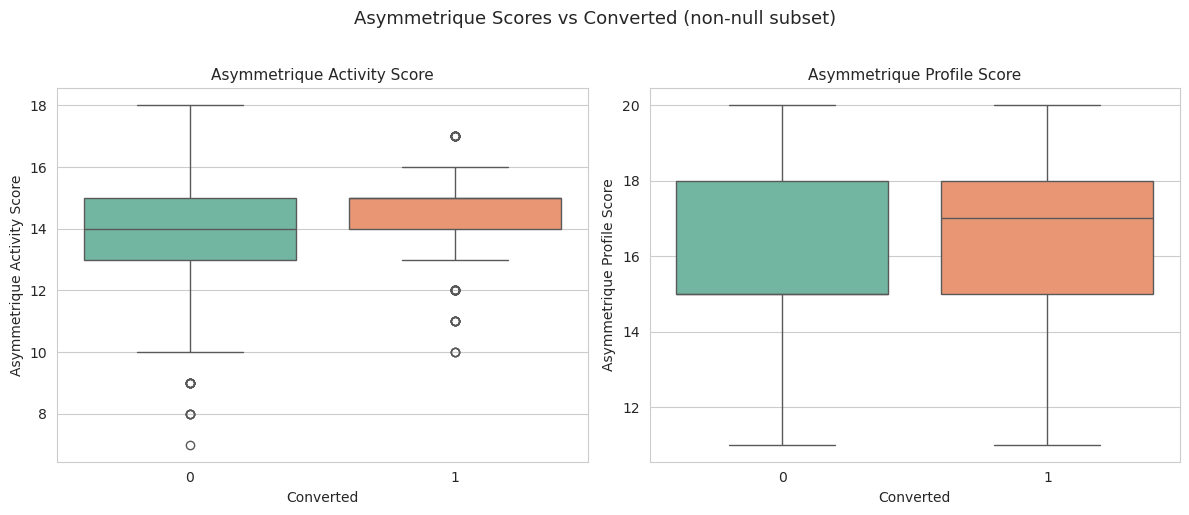

In [8]:
# Asymmetrique scores — subset to rows with scores available
asym_cols = ['Asymmetrique Activity Score', 'Asymmetrique Profile Score']
df_asym = df.dropna(subset=asym_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, asym_cols):
    sns.boxplot(data=df_asym, x='Converted', y=col, ax=ax, palette='Set2')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Converted')
    ax.set_ylabel(col)
plt.suptitle('Asymmetrique Scores vs Converted (non-null subset)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 2.2 Categorical Features vs Target (Conversion Rate %)

Bar charts showing percentage of leads converted per category — not raw counts.


In [9]:
def plot_conversion_rate(df, col, top_n=None, figsize=(10, 4)):
    if top_n:
        top_cats = df[col].value_counts().nlargest(top_n).index
        data = df[df[col].isin(top_cats)]
    else:
        data = df
    rate = data.groupby(col)['Converted'].mean().mul(100).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(rate.index.astype(str), rate.values,
                  color=sns.color_palette('Set2', len(rate)), edgecolor='grey')
    ax.set_title(f'Conversion Rate by {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_xticklabels(rate.index.astype(str), rotation=45, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()


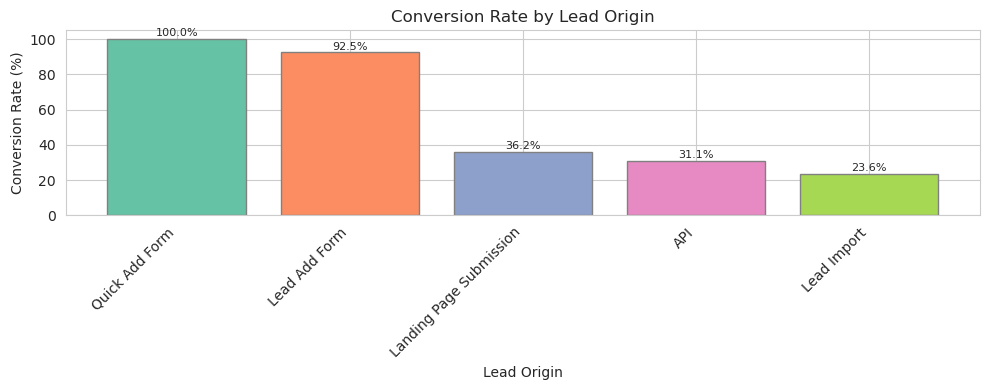

In [10]:
plot_conversion_rate(df, 'Lead Origin')
# Note: Quick Add form is a outlier its a single value but valid

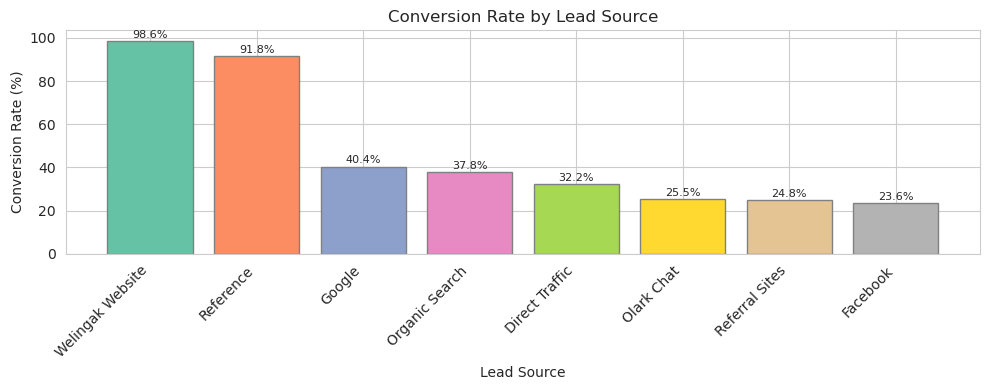

In [11]:
plot_conversion_rate(df, 'Lead Source', top_n=8)


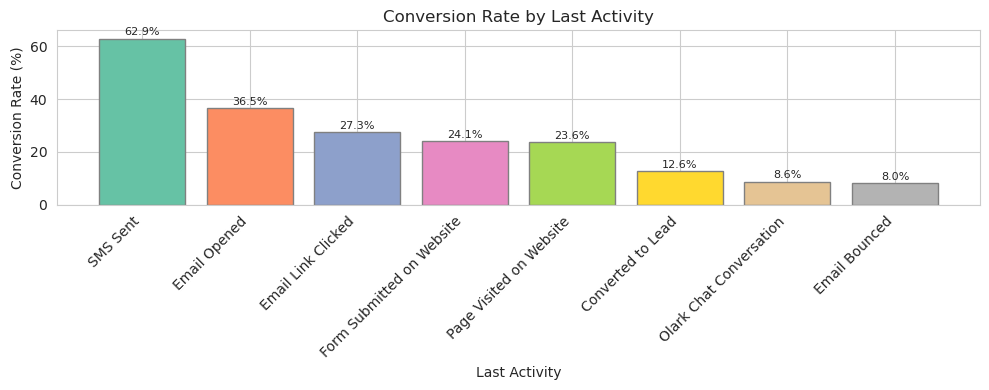

In [12]:
plot_conversion_rate(df, 'Last Activity', top_n=8)


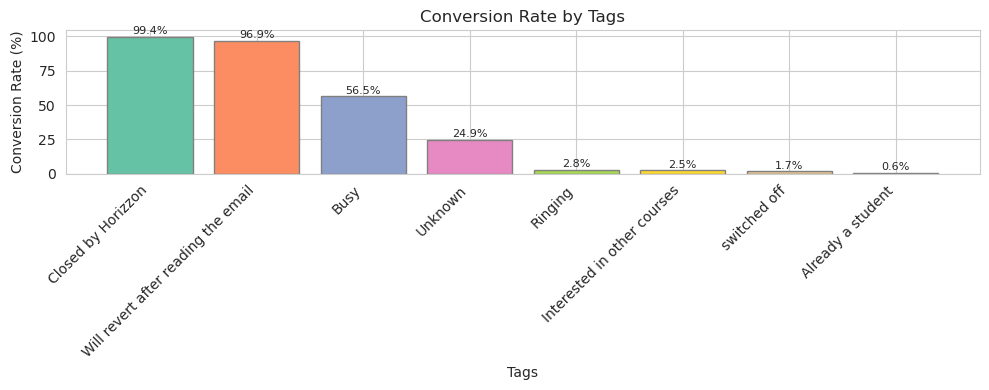

In [13]:
plot_conversion_rate(df, 'Tags', top_n=8)


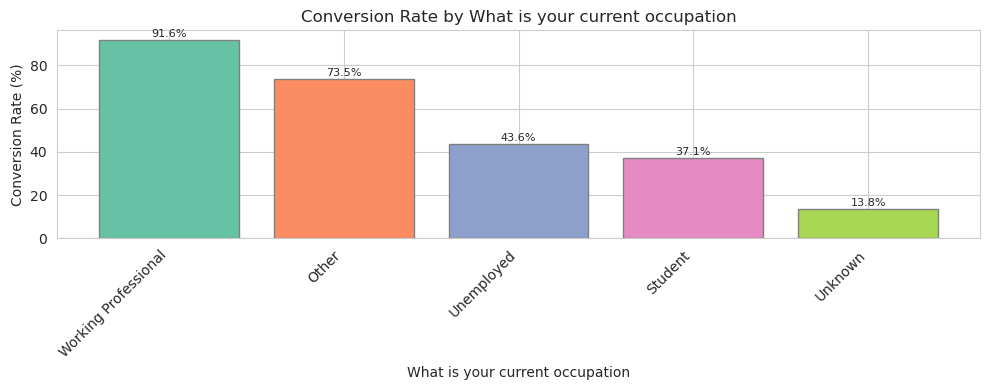

In [14]:
plot_conversion_rate(df, 'What is your current occupation')


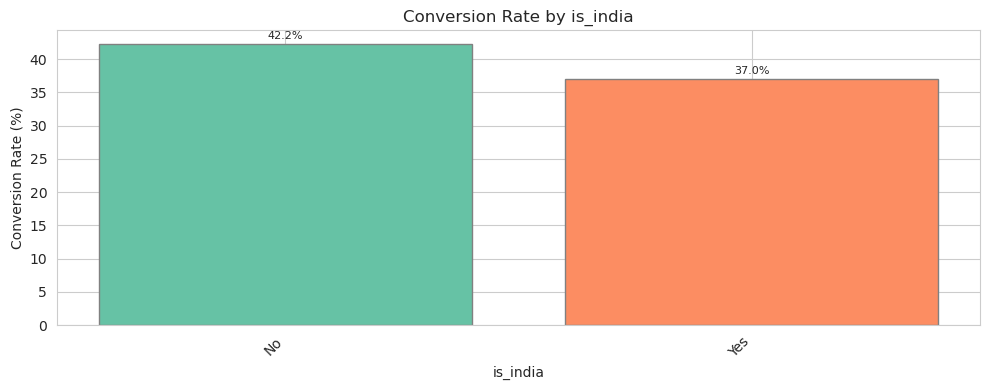

In [15]:
plot_conversion_rate(df, 'is_india')


## 3. Numerical Analysis


### 3.1 Correlation Heatmap


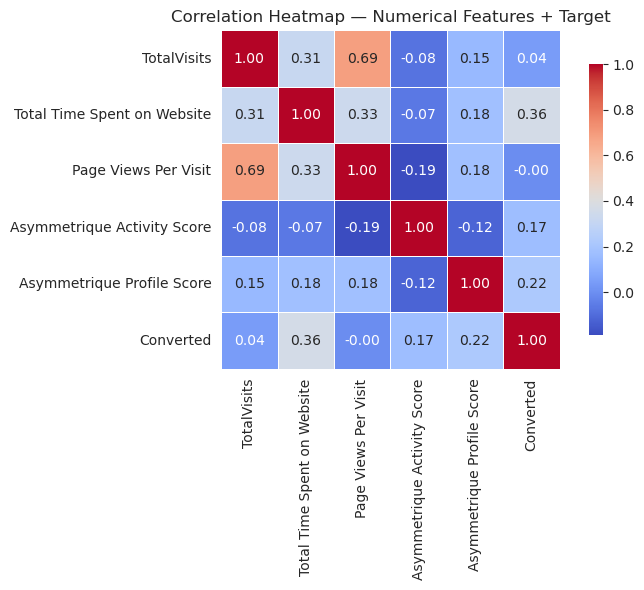

In [16]:
corr_cols = numerical_cols + ['Converted']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features + Target', fontsize=12)
plt.tight_layout()
plt.show()


### 3.2 Descriptive Statistics Split by Target


In [17]:
print('=== Converted = 0 ===')
display(df[df['Converted'] == 0][numerical_cols].describe().T.round(2))


=== Converted = 0 ===


,count,mean,std,min,25%,50%,75%,max
TotalVisits,5679.0,3.24,3.25,0.0,1.0,3.0,4.0,21.0
Total Time Spent on Website,5679.0,330.40,432.23,0.0,16.0,179.0,393.0,2272.0
Page Views Per Visit,5679.0,2.35,2.01,0.0,1.0,2.0,3.0,11.0
Asymmetrique Activity Score,3114.0,14.12,1.59,7.0,13.0,14.0,15.0,18.0
Asymmetrique Profile Score,3114.0,16.04,1.67,11.0,15.0,15.0,18.0,20.0


In [18]:
print('=== Converted = 1 ===')
display(df[df['Converted'] == 1][numerical_cols].describe().T.round(2))


=== Converted = 1 ===


,count,mean,std,min,25%,50%,75%,max
TotalVisits,3561.0,3.54,3.53,0.0,0.0,3.0,5.0,21.0
Total Time Spent on Website,3561.0,738.55,615.66,0.0,0.0,832.0,1268.0,2253.0
Page Views Per Visit,3561.0,2.34,2.05,0.0,0.0,2.0,3.0,11.0
Asymmetrique Activity Score,1908.0,14.60,0.88,10.0,14.0,15.0,15.0,17.0
Asymmetrique Profile Score,1908.0,16.85,1.91,11.0,15.0,17.0,18.0,20.0


## 4. Categorical vs Target — Crosstab Analysis


In [19]:
def show_crosstab(df, col, target='Converted'):
    ct = pd.crosstab(df[col], df[target])
    ct_pct = pd.crosstab(df[col], df[target], normalize='index') * 100
    print(f'\n--- {col} ---')
    print(ct)
    print('\nRow % (conversion rate):')
    print(ct_pct.round(2))


In [20]:
show_crosstab(df, 'Lead Origin')



--- Lead Origin ---
Converted                   0     1
Lead Origin                        
API                      2465  1115
Landing Page Submission  3118  1768
Lead Add Form              54   664
Lead Import                42    13
Quick Add Form              0     1

Row % (conversion rate):
Converted                    0       1
Lead Origin                           
API                      68.85   31.15
Landing Page Submission  63.81   36.19
Lead Add Form             7.52   92.48
Lead Import              76.36   23.64
Quick Add Form            0.00  100.00


In [21]:
show_crosstab(df, 'Lead Source')



--- Lead Source ---
Converted            0     1
Lead Source                 
Direct Traffic    1725   818
Facebook            42    13
Google            1733  1176
Olark Chat        1307   448
Organic Search     718   436
Other               14     9
Reference           44   490
Referral Sites      94    31
Welingak Website     2   140

Row % (conversion rate):
Converted             0      1
Lead Source                   
Direct Traffic    67.83  32.17
Facebook          76.36  23.64
Google            59.57  40.43
Olark Chat        74.47  25.53
Organic Search    62.22  37.78
Other             60.87  39.13
Reference          8.24  91.76
Referral Sites    75.20  24.80
Welingak Website   1.41  98.59


In [22]:
show_crosstab(df, 'Do Not Email')



--- Do Not Email ---
Converted        0     1
Do Not Email            
No            5063  3443
Yes            616   118

Row % (conversion rate):
Converted         0      1
Do Not Email              
No            59.52  40.48
Yes           83.92  16.08


In [23]:
show_crosstab(df, 'Last Activity')



--- Last Activity ---
Converted                     0     1
Last Activity                        
Converted to Lead           374    54
Email Bounced               300    26
Email Link Clicked          194    73
Email Opened               2184  1253
Form Submitted on Website    88    28
Had a Phone Conversation      8    22
Olark Chat Conversation     889    84
Other                         6    15
Page Visited on Website     489   151
SMS Sent                   1018  1727
Unknown                      22    81
Unreachable                  62    31
Unsubscribed                 45    16

Row % (conversion rate):
Converted                      0      1
Last Activity                          
Converted to Lead          87.38  12.62
Email Bounced              92.02   7.98
Email Link Clicked         72.66  27.34
Email Opened               63.54  36.46
Form Submitted on Website  75.86  24.14
Had a Phone Conversation   26.67  73.33
Olark Chat Conversation    91.37   8.63
Other                

In [24]:
show_crosstab(df, 'Specialization')



--- Specialization ---
Converted                             0    1
Specialization                              
Banking, Investment And Insurance   171  167
Business Administration             224  179
E-COMMERCE                           72   40
Finance Management                  540  436
Healthcare Management                80   79
Hospitality Management               66   48
Human Resource Management           460  388
IT Projects Management              226  140
International Business              114   64
Marketing Management                430  408
Media and Advertising               118   85
Not Specified                      2411  969
Operations Management               265  238
Other                               107   63
Retail Management                    66   34
Supply Chain Management             198  151
Travel and Tourism                  131   72

Row % (conversion rate):
Converted                              0      1
Specialization                                 

In [25]:
show_crosstab(df, 'What is your current occupation')



--- What is your current occupation ---
Converted                           0     1
What is your current occupation            
Other                               9    25
Student                           132    78
Unemployed                       3159  2441
Unknown                          2320   370
Working Professional               59   647

Row % (conversion rate):
Converted                            0      1
What is your current occupation              
Other                            26.47  73.53
Student                          62.86  37.14
Unemployed                       56.41  43.59
Unknown                          86.25  13.75
Working Professional              8.36  91.64


In [26]:
show_crosstab(df, 'Tags')
# Note Tags suspected as data leakage feature will test it in base model 


--- Tags ---
Converted                               0     1
Tags                                           
Already a student                     462     3
Busy                                   81   105
Closed by Horizzon                      2   356
Diploma holder (Not Eligible)          62     1
Graduation in progress                104     7
Interested  in full time MBA          114     3
Interested in other courses           500    13
Lost to EINS                            4   171
Not doing further education           144     1
Other                                 137    19
Ringing                              1169    34
Unknown                              2517   836
Will revert after reading the email    65  2007
invalid number                         82     1
switched off                          236     4

Row % (conversion rate):
Converted                                0      1
Tags                                             
Already a student                    99.35  

In [27]:
show_crosstab(df, 'City')



--- City ---
Converted                       0     1
City                                   
Metro Cities                  225   155
Mumbai                       1913  1309
Other Cities                  410   276
Other Cities of Maharashtra   256   201
Thane & Outskirts             414   338
Tier II Cities                 49    25
Unknown                      2412  1257

Row % (conversion rate):
Converted                        0      1
City                                     
Metro Cities                 59.21  40.79
Mumbai                       59.37  40.63
Other Cities                 59.77  40.23
Other Cities of Maharashtra  56.02  43.98
Thane & Outskirts            55.05  44.95
Tier II Cities               66.22  33.78
Unknown                      65.74  34.26


In [28]:
show_crosstab(df, 'A free copy of Mastering The Interview')



--- A free copy of Mastering The Interview ---
Converted                                  0     1
A free copy of Mastering The Interview            
No                                      3821  2531
Yes                                     1858  1030

Row % (conversion rate):
Converted                                   0      1
A free copy of Mastering The Interview              
No                                      60.15  39.85
Yes                                     64.34  35.66


In [29]:
show_crosstab(df, 'Last Notable Activity')



--- Last Notable Activity ---
Converted                   0     1
Last Notable Activity              
Email Bounced              51     9
Email Link Clicked        128    45
Email Opened             1783  1044
Modified                 2624   783
Olark Chat Conversation   158    25
Other                      46    54
Page Visited on Website   225    93
SMS Sent                  664  1508

Row % (conversion rate):
Converted                    0      1
Last Notable Activity                
Email Bounced            85.00  15.00
Email Link Clicked       73.99  26.01
Email Opened             63.07  36.93
Modified                 77.02  22.98
Olark Chat Conversation  86.34  13.66
Other                    46.00  54.00
Page Visited on Website  70.75  29.25
SMS Sent                 30.57  69.43


In [30]:
show_crosstab(df, 'is_india')



--- is_india ---
Converted     0     1
is_india             
No         1588  1160
Yes        4091  2401

Row % (conversion rate):
Converted      0      1
is_india               
No         57.79  42.21
Yes        63.02  36.98


## 5. Categorical vs Categorical — Cramér's V Association


In [31]:
import warnings
warnings.filterwarnings('ignore')

# All categorical columns + target treated as categorical for association analysis
categorical_cols_cv = categorical_cols + ['Converted']

# Ensure consistent object types
df_cv = df[categorical_cols_cv].copy()
df_cv['Converted'] = df_cv['Converted'].astype(str)
df_cv = df_cv.astype('object')

# Fill nulls for analysis only — does not modify df
df_filled = df_cv.fillna('missing')

# Bias-corrected Cramér's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Compute all pairwise associations
results_per_feature = {}

for i, feat1 in enumerate(categorical_cols_cv):
    records = []
    for j, feat2 in enumerate(categorical_cols_cv):
        if i == j:
            continue
        crosstab = pd.crosstab(df_filled[feat1], df_filled[feat2])
        try:
            chi2, p, dof, expected = chi2_contingency(crosstab)
            v = cramers_v(crosstab)
        except:
            chi2, p, v = np.nan, np.nan, np.nan
        records.append({'feature_2': feat2, 'cramers_v': v, 'p_value': p, 'chi2': chi2})
    df_pair = pd.DataFrame(records)
    df_pair = df_pair.sort_values('cramers_v', ascending=False).reset_index(drop=True)
    results_per_feature[feat1] = df_pair

# Display results per feature
for feat, df_res in results_per_feature.items():
    print(f"\n{'=' * 80}")
    print(f' Associations for feature: {feat}')
    print('=' * 80)
    print(df_res.to_string(index=False))
    print()



 Associations for feature: Lead Origin
                             feature_2  cramers_v       p_value         chi2
                           Lead Source   0.769683  0.000000e+00 21918.082333
                              is_india   0.627460  0.000000e+00  3641.451090
A free copy of Mastering The Interview   0.569345  0.000000e+00  2998.860408
                                  City   0.417248  0.000000e+00  6455.786303
                        Specialization   0.393541  0.000000e+00  5785.705062
                             Converted   0.325482 1.938318e-211   982.765781
                         Last Activity   0.272006  0.000000e+00  2781.396310
                                  Tags   0.242499  0.000000e+00  2228.524079
       What is your current occupation   0.146763 1.968469e-162   811.752112
                 Last Notable Activity   0.105567  1.566644e-75   439.724916
                          Do Not Email   0.100734  2.960871e-20    97.751507


 Associations for feature: Lead So

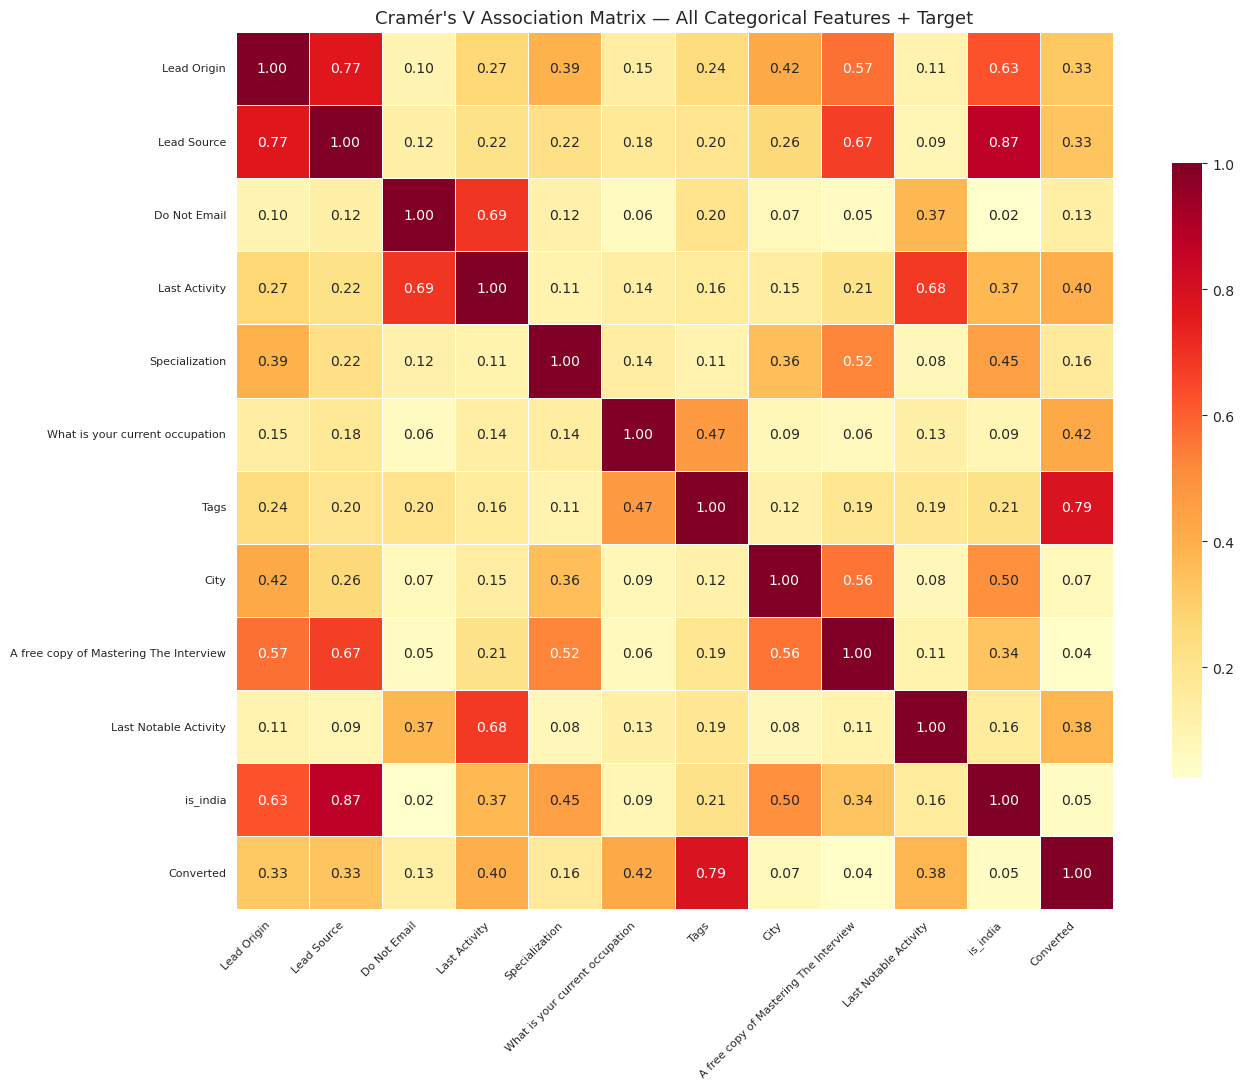

In [32]:
# Full symmetric Cramér's V matrix — heatmap
n_cols = len(categorical_cols_cv)
cv_matrix = pd.DataFrame(
    np.zeros((n_cols, n_cols)),
    index=categorical_cols_cv,
    columns=categorical_cols_cv
)

for feat1 in categorical_cols_cv:
    for feat2 in categorical_cols_cv:
        if feat1 == feat2:
            cv_matrix.loc[feat1, feat2] = 1.0
        else:
            crosstab = pd.crosstab(df_filled[feat1], df_filled[feat2])
            try:
                v = cramers_v(crosstab)
            except:
                v = np.nan
            cv_matrix.loc[feat1, feat2] = v

plt.figure(figsize=(14, 11))
sns.heatmap(
    cv_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
    square=True, linewidths=0.4, cbar_kws={'shrink': 0.7},
    xticklabels=True, yticklabels=True
)
plt.title("Cramér's V Association Matrix — All Categorical Features + Target", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


In [35]:
df = df.drop(columns=['Tags', 'City', 'A free copy of Mastering The Interview', 'is_india', 'Last Notable Activity', "TotalVisits", "Page Views Per Visit", "Lead Source"])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Lead Origin                      9240 non-null   object 
 1   Do Not Email                     9240 non-null   object 
 2   Converted                        9240 non-null   int64  
 3   Total Time Spent on Website      9240 non-null   int64  
 4   Last Activity                    9240 non-null   object 
 5   Specialization                   9240 non-null   object 
 6   What is your current occupation  9240 non-null   object 
 7   Asymmetrique Activity Score      5022 non-null   float64
 8   Asymmetrique Profile Score       5022 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 649.8+ KB


In [37]:
small_tags = df['Specialization'].value_counts()
small_tags = small_tags[small_tags < 200].index.tolist()

df['Specialization'] = df['Specialization'].apply(
    lambda x: 'Other' if x in small_tags else x
)

df['Specialization'].value_counts()

Specialization
Not Specified                        3380
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Other                                 833
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Media and Advertising                 203
Travel and Tourism                    203
Name: count, dtype: int64

In [38]:
df['What is your current occupation'].value_counts()

What is your current occupation
Unemployed              5600
Unknown                 2690
Working Professional     706
Student                  210
Other                     34
Name: count, dtype: int64

In [40]:
df['occupation_known'] = df['What is your current occupation'] != 'Unknown'

In [42]:
df['occupation_known'].value_counts()

occupation_known
True     6550
False    2690
Name: count, dtype: int64

In [45]:
df = df[df['Lead Origin'] != 'Quick Add Form']

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9239 entries, 0 to 9239
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Lead Origin                      9239 non-null   object 
 1   Do Not Email                     9239 non-null   object 
 2   Converted                        9239 non-null   int64  
 3   Total Time Spent on Website      9239 non-null   int64  
 4   Last Activity                    9239 non-null   object 
 5   Specialization                   9239 non-null   object 
 6   What is your current occupation  9239 non-null   object 
 7   Asymmetrique Activity Score      5021 non-null   float64
 8   Asymmetrique Profile Score       5021 non-null   float64
 9   occupation_known                 9239 non-null   bool   
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 730.8+ KB


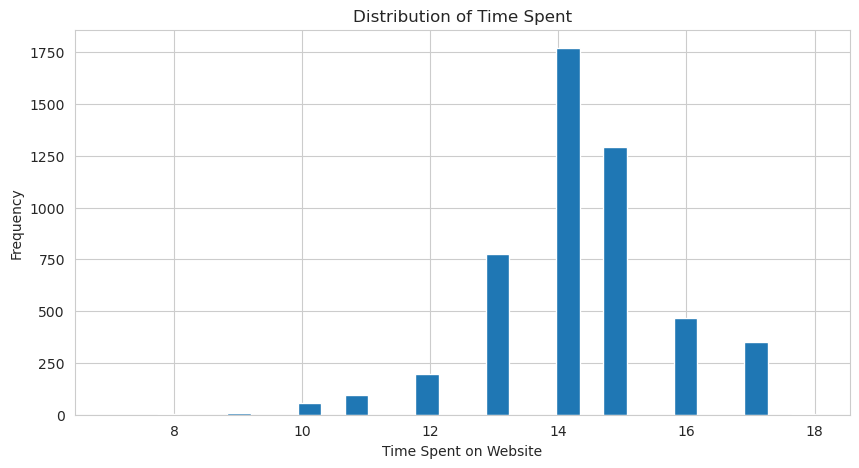

In [52]:
import matplotlib.pyplot as plt

col = 'Asymmetrique Activity Score'

plt.figure()
plt.hist(df[col].dropna(), bins=30)
plt.xlabel('Time Spent on Website')
plt.ylabel('Frequency')
plt.title('Distribution of Time Spent')
plt.show()

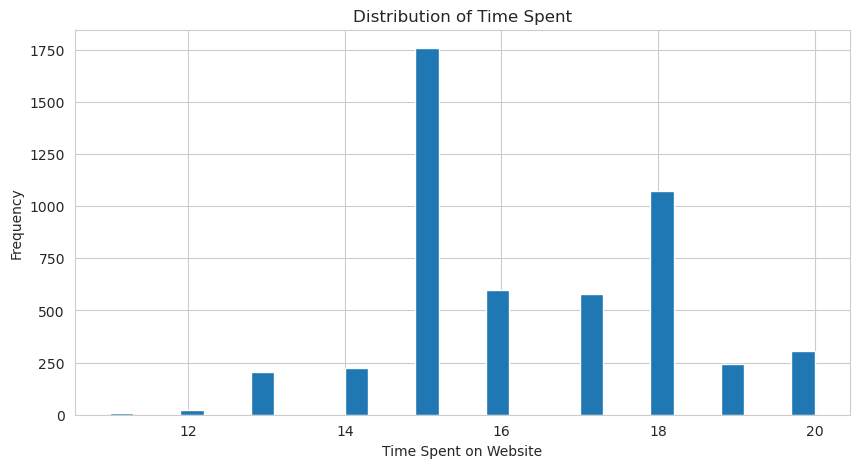

In [53]:
import matplotlib.pyplot as plt

col = 'Asymmetrique Profile Score'

plt.figure()
plt.hist(df[col].dropna(), bins=30)
plt.xlabel('Time Spent on Website')
plt.ylabel('Frequency')
plt.title('Distribution of Time Spent')
plt.show()

## 6. Key Takeaways

- Drop: 
    - Tags (Data leakage),
    - City (V=0.12, no signal),
    - A free copy... (Low Cramer's V score with target),
    - is_india (redundant with Lead Source),
    - Last Notable Activity (duplicate of Last Activity),
    - Total Visits & Page Views (weakest correlation, Total Time Spent better).
    - Lead Source (redundant with Lead Origin)

- Fix/Merge: 
    - Specialization (merge n<200 into Other).
    - Create: occupation_known (binary flag).
    - Drop: Quick add form row from Lead Origin.

- Strong Features : 
    - Lead Source 
    - Last Activity 
    - Total Time Spent 
    - Asymmetrique Scores

- Scale (for Linear Reg only): 
    - Time Spent = StandardScaler after log Transformation.
    - Asymmetrique Scores = StandardScaler

In [55]:
df.to_csv('finalized_feas.csv', index=False)